In [ ]:
!gdown 14lX_JgofYZLbIkjPf7rXmBOpVIfMudDo -O kaggle.json
!mkdir -p /root/.kaggle
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

!kaggle datasets download thedevastator/dailydialog-multi-turn-dialog-with-intention-and
!unzip dailydialog-multi-turn-dialog-with-intention-and.zip -d .

Downloading...
From: https://drive.google.com/uc?id=14lX_JgofYZLbIkjPf7rXmBOpVIfMudDo
To: /content/kaggle.json
100% 69.0/69.0 [00:00<00:00, 307kB/s]


In [ ]:
import pandas as pd
import re
import ast

In [ ]:
def fix_and_eval_list(s):
    if isinstance(s, list): return s
    s_fixed = re.sub(r"(\d)\s+(?=\d)", r"\1, ", s)
    return ast.literal_eval(s_fixed)

def parse_dialog(s):
    utterances = re.findall(r"'(.*?)'|\"(.*?)\"", s)
    return [u[0] if u[0] else u[1] for u in utterances]

def load_and_prepare_flat_df(path, tokenizer, max_length=64):
    # Load CSV
    df = pd.read_csv(path)

    # Parse columns
    df["dialog"] = df["dialog"].apply(parse_dialog)
    df["act"] = df["act"].apply(fix_and_eval_list)
    df["emotion"] = df["emotion"].apply(fix_and_eval_list)

    # Flatten
    rows = []
    for dialog_id, row in df.iterrows():
        for turn_id, (utt, emo) in enumerate(zip(row["dialog"], row["emotion"])):
            rows.append({
                "dialog_id": dialog_id,
                "turn_id": turn_id,
                "utterance": utt,
                "label": emo
            })
    df_flat = pd.DataFrame(rows)

    # Tokenize
    tokenized = tokenizer(
        df_flat["utterance"].tolist(),
        padding=True,
        truncation=True,
        max_length=max_length
    )
    df_flat["input_ids"] = tokenized["input_ids"]
    df_flat["attention_mask"] = tokenized["attention_mask"]

    return df_flat


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

# Process train and validation
df_train_flat = load_and_prepare_flat_df("train.csv", tokenizer)
df_val_flat = load_and_prepare_flat_df("validation.csv", tokenizer)

# Preview
df_train_flat.head()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

,dialog_id,turn_id,utterance,label,input_ids,attention_mask
0,0,0,"Say , Jim , how about going for a few beers af...",0,"[0, 34673, 2156, 2488, 2156, 141, 59, 164, 13,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,0,1,You know that is tempting but is really not g...,0,"[0, 370, 216, 14, 16, 25057, 53, 16, 269, 45, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,0,2,What do you mean ? It will help us to relax .,0,"[0, 653, 109, 47, 1266, 17487, 85, 40, 244, 20...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,0,3,Do you really think so ? I don't . It will ju...,0,"[0, 1832, 47, 269, 206, 98, 17487, 38, 218, 75...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,0,4,I guess you are right.But what shall we do ? ...,0,"[0, 38, 4443, 47, 32, 235, 4, 1708, 99, 5658, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [ ]:
df_val_flat.head()

,dialog_id,turn_id,utterance,label,input_ids,attention_mask
0,0,0,"Good morning , sir . Is there a bank near here ?",0,"[0, 12350, 662, 2156, 21958, 479, 1534, 89, 10...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,0,1,There is one . 5 blocks away from here ?,0,"[0, 345, 16, 65, 479, 195, 5491, 409, 31, 259,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, ..."
2,0,2,"Well , that's too far.Can you change some mon...",0,"[0, 2647, 2156, 14, 18, 350, 444, 4, 10836, 47...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,0,3,"Surely , of course . What kind of currency ha...",0,"[0, 28086, 2156, 9, 768, 479, 653, 761, 9, 259...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,0,4,RIB .,0,"[0, 248, 8863, 479, 1437, 2, 1, 1, 1, 1, 1, 1,...","[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

# Convert to NumPy array (explicitly)
classes = np.array(sorted(df_train_flat["label"].unique()))

# Compute balanced class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=df_train_flat["label"].values
)

# Convert to torch tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

# Print class weights
for i, w in zip(classes, class_weights_tensor):
    print(f"Class {i}: weight = {w:.4f}")


Class 0: weight = 0.1726
Class 1: weight = 15.0579
Class 2: weight = 41.0985
Class 3: weight = 85.2935
Class 4: weight = 1.1137
Class 5: weight = 12.8512
Class 6: weight = 7.7830


In [ ]:
!pip install -q datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 17.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-nvrtc-cu12

In [ ]:
from datasets import Dataset

# Select only the required columns for the model
hf_train_dataset = Dataset.from_pandas(df_train_flat[["input_ids", "attention_mask", "label"]])
hf_val_dataset = Dataset.from_pandas(df_val_flat[["input_ids", "attention_mask", "label"]])

print(hf_train_dataset.features)


{'input_ids': Sequence(feature=Value(dtype='int64', id=None), length=-1, id=None), 'attention_mask': Sequence(feature=Value(dtype='int64', id=None), length=-1, id=None), 'label': Value(dtype='int64', id=None)}


In [ ]:
from datasets import DatasetDict

# Load and prepare test set as well
df_test_flat = load_and_prepare_flat_df("test.csv", tokenizer)

# Convert also test to Hugging Face Dataset
hf_test_dataset = Dataset.from_pandas(df_test_flat[["input_ids", "attention_mask", "label"]])

# Bundle all into a DatasetDict
dataset_dict = DatasetDict({
    "train": hf_train_dataset,
    "validation": hf_val_dataset,
    "test": hf_test_dataset
})

# Check structure
dataset_dict


DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'label'],
        num_rows: 87170
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'label'],
        num_rows: 8069
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'label'],
        num_rows: 7740
    })
})

In [ ]:
from transformers import RobertaForSequenceClassification

model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=7
)

for name, param in model.roberta.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps",
    eval_steps=500,
    save_steps=500,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro_wo_neutral",
    greater_is_better=True,
    logging_steps=500,
    learning_rate=1e-4,
    per_device_train_batch_size=256,
    per_device_eval_batch_size=256,
    num_train_epochs=10,
    weight_decay=0.01,
    logging_dir="./logs",
    report_to="none",
    fp16=True,
)


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro_wo_neutral": f1_score(labels, preds, average="macro", labels=[1,2,3,4,5,6]),
        "f1_micro_wo_neutral": f1_score(labels, preds, average="micro", labels=[1,2,3,4,5,6]),
        "f1_macro_all": f1_score(labels, preds, average="macro", labels=[0,1,2,3,4,5,6]),
    }


In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict["train"],
    eval_dataset=dataset_dict["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()


<ipython-input-15-704a87702c9f>:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss,Validation Loss,Accuracy,F1 Macro Wo Neutral,F1 Micro Wo Neutral,F1 Macro All
500,0.439100,0.266240,0.899492,0.258402,0.537623,0.356614
1000,0.368600,0.272480,0.899616,0.239210,0.561224,0.340237
1500,0.335100,0.267932,0.900359,0.338195,0.565503,0.425183
2000,0.304200,0.276866,0.894659,0.300820,0.563380,0.392575
2500,0.273900,0.286398,0.894535,0.321426,0.565617,0.410193
3000,0.250300,0.296037,0.894783,0.330040,0.565657,0.417670


TrainOutput(global_step=3410, training_loss=0.31742366891452645, metrics={'train_runtime': 1061.6509, 'train_samples_per_second': 821.08, 'train_steps_per_second': 3.212, 'total_flos': 2.867052541728e+16, 'train_loss': 0.31742366891452645, 'epoch': 10.0})

In [ ]:
import shutil
shutil.make_archive("results_zipped", "zip", "results")


'/content/results_zipped.zip'

In [ ]:
eval_results = trainer.evaluate(eval_dataset=dataset_dict["test"])
print("Test set evaluation:", eval_results)


Test set evaluation: {'eval_loss': 0.4199315905570984, 'eval_accuracy': 0.8476744186046512, 'eval_f1_macro_wo_neutral': 0.40494670811435735, 'eval_f1_micro_wo_neutral': 0.5246277205040092, 'eval_f1_macro_all': 0.47759136346154485, 'eval_runtime': 6.1606, 'eval_samples_per_second': 1256.362, 'eval_steps_per_second': 5.032, 'epoch': 10.0}


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

predictions = trainer.predict(dataset_dict["test"])

y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

target_names = [
    "no emotion",  # 0
    "anger",       # 1
    "disgust",     # 2
    "fear",        # 3
    "happiness",   # 4
    "sadness",     # 5
    "surprise"     # 6
]

print(classification_report(y_true, y_pred, target_names=target_names, digits=3))


              precision    recall  f1-score   support

  no emotion      0.898     0.929     0.913      6321
       anger      0.410     0.271     0.327       118
     disgust      0.632     0.255     0.364        47
        fear      0.571     0.235     0.333        17
   happiness      0.640     0.526     0.578      1019
     sadness      0.383     0.304     0.339       102
    surprise      0.404     0.621     0.490       116

    accuracy                          0.848      7740
   macro avg      0.563     0.449     0.478      7740
weighted avg      0.840     0.848     0.842      7740



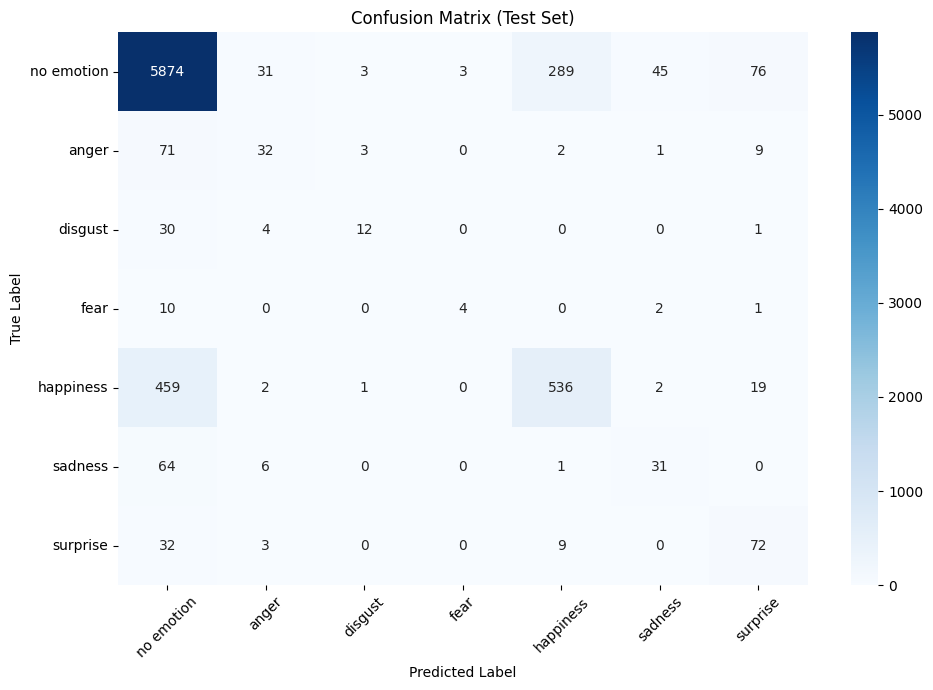

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

predictions = trainer.predict(dataset_dict["test"])
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)
labels = [
    "no emotion", "anger", "disgust", "fear", "happiness", "sadness", "surprise"
]

# 📊 Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Test Set)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
trainer.save_model("./best_model")
tokenizer.save_pretrained("./best_model")


('./best_model/tokenizer_config.json',
 './best_model/special_tokens_map.json',
 './best_model/vocab.json',
 './best_model/merges.txt',
 './best_model/added_tokens.json',
 './best_model/tokenizer.json')